# Regresión lineal con red neuronal (PyTorch)

Predecir salario a partir de años de experiencia con el **dataset Salary**. Código para ejecutar en **PyCharm** (o Jupyter).

- **Carga de datos:** solo **pandas** y **NumPy** (leer CSV, normalizar).
- **Modelo y predicciones:** red neuronal con **PyTorch** (sin Keras ni TensorFlow).

## 1. Carga y preproceso (pandas + NumPy)

Solo usamos pandas y NumPy para descargar y preparar los datos.

In [7]:
# --- Librerías solo para carga y preproceso de datos ---
import numpy as np   # Arrays numéricos (formas, tipos, estadísticos)
import pandas as pd  # Lectura de CSV y manejo tabular

# URL del dataset clásico Salary (años de experiencia → salario)
url = 'https://raw.githubusercontent.com/Dragan-Manevski/Simple_Linear_Regression-Salary_Data/main/Salary_Data.csv'

# Cargar CSV en un DataFrame; strip elimina espacios en nombres de columnas
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
# Eliminar filas con valores faltantes (por si el CSV tiene huecos)
df = df.dropna()

# Extraer variables: X = entrada (1 feature), y = salida a predecir
# reshape(-1, 1) asegura forma (n, 1) para compatibilidad con PyTorch
# float32 es el tipo habitual para tensores en GPU/CPU
x = df['YearsExperience'].values.reshape(-1, 1).astype(np.float32)
y = df['Salary'].values.reshape(-1, 1).astype(np.float32)

# Normalización: media 0 y desviación ~1 para estabilidad del entrenamiento
# 1e-8 evita división por cero si std es 0
x_mean, x_std = x.mean(), x.std()
y_mean, y_std = y.mean(), y.std()
x = (x - x_mean) / (x_std + 1e-8)
y = (y - y_mean) / (y_std + 1e-8)

# Inspección rápida: primeras filas y dimensiones
print(df.head())
print('Forma X:', x.shape, '| Forma y:', y.shape)

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0
Forma X: (30, 1) | Forma y: (30, 1)


## 2. Red neuronal con PyTorch (modelo predictivo)

Definimos la red, entrenamos y hacemos predicciones. Todo el modelo es PyTorch.

In [8]:
# --- Red neuronal y entrenamiento con PyTorch (modelo predictivo) ---
import torch
import torch.nn as nn

# Usar GPU si está disponible; si no, CPU (no requiere instalación extra)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Definición de la red: heredamos de nn.Module (requisito de PyTorch)
class RedRegresion(nn.Module):
    def __init__(self):
        super().__init__()
        # Capa totalmente conectada: 1 entrada (años exp.) → 8 neuronas ocultas
        self.fc1 = nn.Linear(1, 8)
        # Capa de salida: 8 → 1 (un único valor de salida para regresión)
        self.fc2 = nn.Linear(8, 1)

    # forward define el flujo de datos (entrada → salida)
    def forward(self, x):
        # Oculta: lineal + ReLU (no linealidad; salida >= 0)
        x = torch.relu(self.fc1(x))
        # Salida lineal (sin activación): valor continuo para regresión
        return self.fc2(x)

# Instanciar modelo y moverlo al device (GPU/CPU)
model = RedRegresion().to(device)
# Pérdida: error cuadrático medio (típico en regresión)
criterion = nn.MSELoss()
# Optimizador Adam: actualiza pesos según gradientes (lr = learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

# Convertir arrays NumPy a tensores PyTorch y enviarlos al device
X_t = torch.from_numpy(x).to(device)
Y_t = torch.from_numpy(y).to(device)

# Entrenamiento por épocas
epochs = 400
losses = []
model.train()  # Modo entrenamiento (activa dropout/batchnorm si los hubiera)
for ep in range(epochs):
    optimizer.zero_grad()   # Poner a cero los gradientes de la época anterior
    pred = model(X_t)       # Forward: predicción con los pesos actuales
    loss = criterion(pred, Y_t)  # Calcular MSE entre predicción y objetivo
    loss.backward()         # Backpropagation: calcular gradientes
    optimizer.step()       # Actualizar pesos con los gradientes
    losses.append(loss.item())  # Guardar valor escalar de la pérdida (para gráfico)

# Modo evaluación: desactivar comportamiento de entrenamiento
model.eval()
# Predicción final sin calcular gradientes (ahorra memoria y tiempo)
with torch.no_grad():
    y_pred = model(X_t).cpu().numpy()  # Volver a CPU y a NumPy para visualizar

print(f'MSE final: {losses[-1]:.6f}')

MSE final: 0.031112


## 3. Visualización

Datos y predicción de la red (valores desnormalizados).

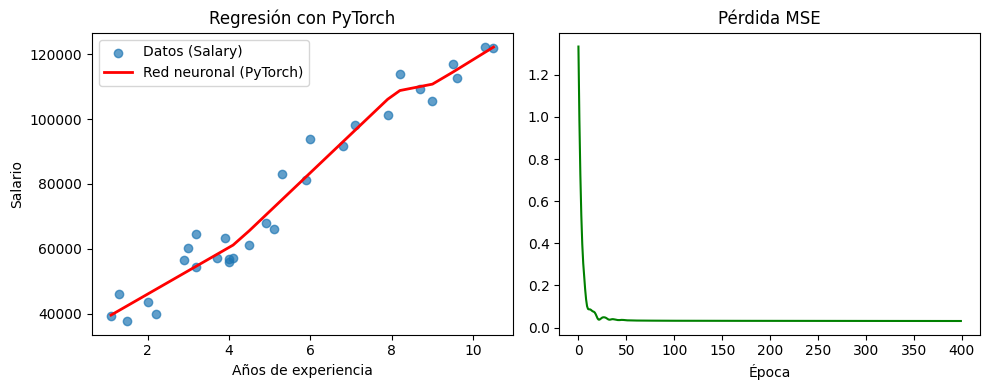

In [9]:
import matplotlib.pyplot as plt

# Desnormalizar para mostrar datos y predicción en unidades originales (años, euros/dólares)
x_orig = x * x_std + x_mean
y_orig = y * y_std + y_mean
y_pred_orig = y_pred * y_std + y_mean

# Dos subplots: izquierda = datos + curva; derecha = curva de aprendizaje
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Izquierda: puntos = datos reales; línea = predicción de la red
ax1.scatter(x_orig, y_orig, alpha=0.7, label='Datos (Salary)')
ax1.plot(x_orig, y_pred_orig, color='red', linewidth=2, label='Red neuronal (PyTorch)')
ax1.set_xlabel('Años de experiencia')
ax1.set_ylabel('Salario')
ax1.legend()
ax1.set_title('Regresión con PyTorch')

# Derecha: evolución del error (MSE) a lo largo de las épocas
ax2.plot(losses, color='green')
ax2.set_xlabel('Época')
ax2.set_title('Pérdida MSE')
plt.tight_layout()
plt.show()